<a href="https://colab.research.google.com/github/SudhanshuJamwal/Coursera_IBM_datascience/blob/main/End_point_temperature.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


After running the above cell and following the authentication steps, your Google Drive will be mounted at `/content/drive`. You can then access your files in the 'My Drive' folder, for example: `/content/drive/My Drive/path/to/your/file.csv`.

In [6]:
import pandas as pd

file_path = '/content/drive/MyDrive/CoDE projects data/STEEL_PROC_ANALYSIS_MATCHED.csv'
df = pd.read_csv(file_path)

print(f"Data loaded successfully. Shape of the DataFrame: {df.shape}")
print(df.head())

Data loaded successfully. Shape of the DataFrame: (15291, 118)
   HEATNO  REHEAT_NO  BSP_HEATNO  BSP_REHEAT_NO CONVERTOR_ID  LINING_LIFE  \
0   93364          0       93306            NaN            C         1279   

       TAPPING_DATE   PROD_DATE  HEAT_YEAR  LANCE  ...  W_VALUE FE_P_FLAG  \
0  01-01-2025 00:21  31-12-2024       2024    NaN  ...      NaN       NaN   

   FE_P_VALUE SB_VALUE_1 N_VALUE SN_VALUE_1 CA_VALUE CA_FLAG  \
0     98.9581        NaN     NaN        NaN   0.0016     NaN   

            RECV_DT MES_FLAG  
0  01-01-2025 07:42        N  

[1 rows x 118 columns]


/tmp/ipython-input-913876113.py:4: DtypeWarning: Columns (81,105) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [9]:
print(df.columns.tolist())

['HEATNO', 'REHEAT_NO', 'BSP_HEATNO', 'BSP_REHEAT_NO', 'CONVERTOR_ID', 'LINING_LIFE', 'TAPPING_DATE', 'PROD_DATE', 'HEAT_YEAR', 'LANCE', 'NO_OF_BLOWS', 'BLOW_START_1', 'BLOW_END', 'BLOW_END_1', 'BLOW_START_2', 'BLOW_END_2', 'BLOW_START_3', 'BLOW_END_3', 'BLOW_START_4', 'BLOW_END_4', 'BLOW_START_5', 'BLOW_END_5', 'BL_OXYGEN_1', 'BL_OXYGEN_2', 'BL_OXYGEN_3', 'BL_OXYGEN_4', 'BL_OXYGEN_5', 'TAP_START', 'TAP_END', 'TOT_OXYGEN', 'TD_TEMP', 'TD_TEMP_TIME', 'LADLE_NO', 'ARGON_TEMP', 'ARGON_TEMP_TIME', 'ARGON_2TEMP', 'ARGON_2TEMP_TIME', 'AIM_GRADE', 'TAPPED_GRADE', 'HM_SI', 'HM_MN', 'HM_P', 'HM_S', 'CASTER_NO', 'CAST_START', 'CAST_END', 'BILLET_BLOOM', 'CASTING_PIECE', 'CASTING_WT', 'CASTING_STATUS', 'INS_UPD_DATE', 'LF_NO', 'LF_ARC_START', 'LF_ARC_END', 'RH_NO', 'RH_DEGASS_START', 'RH_DEGASS_END', 'CASTER_SEQ', 'STEEL_WT', 'HOT_METAL_LADLE', 'PKEY', 'TEST_DT', 'MC_NO', 'PROGRAM_NAME', 'TASK_NAME', 'RUN_PERFORMED', 'RUNS_AVERAGE', 'RUN_NUMBER', 'RESULT_TYPE', 'TYPE_STANDARD_NAME', 'SID2', 'SID3

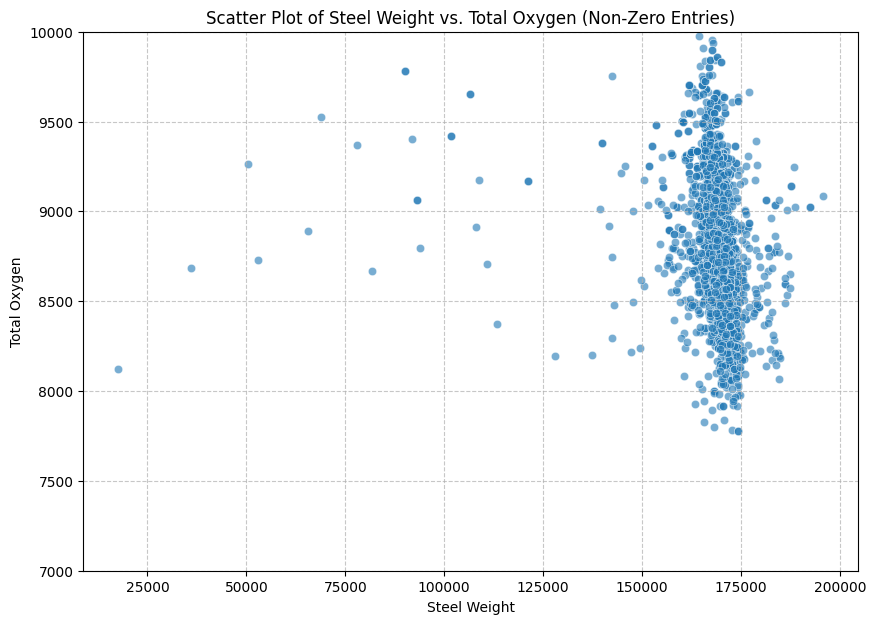

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out non-zero entries for both 'TOT_OXYGEN' and 'STEEL_WT'
df_filtered = df[(df['TOT_OXYGEN'] != 0) & (df['STEEL_WT'] != 0)]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_filtered, x='STEEL_WT', y='TOT_OXYGEN', alpha=0.6)
plt.title('Scatter Plot of Steel Weight vs. Total Oxygen (Non-Zero Entries)')
plt.xlabel('Steel Weight')
plt.ylabel('Total Oxygen')
plt.ylim(7000, 10000)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

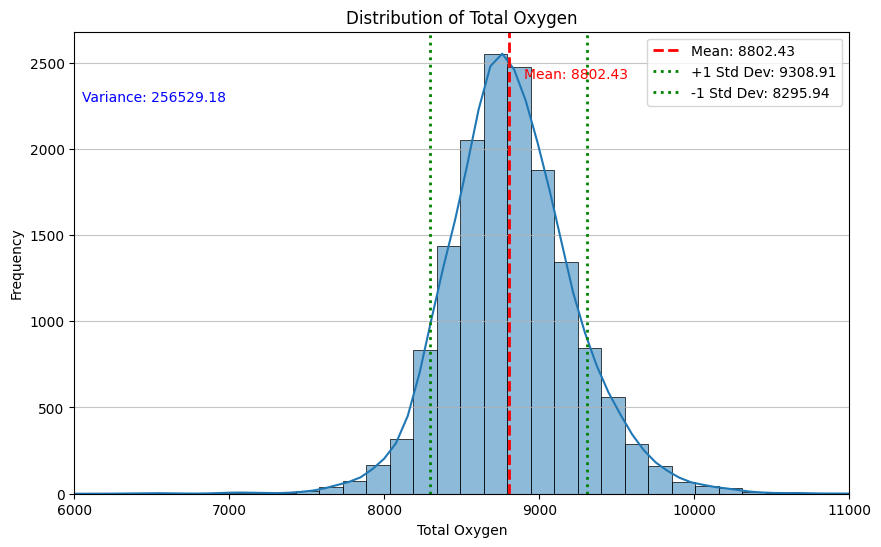

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for standard deviation calculation

plt.figure(figsize=(10, 6))
sns.histplot(df['TOT_OXYGEN'], bins=100, kde=True)
plt.title('Distribution of Total Oxygen')
plt.xlabel('Total Oxygen')
plt.ylabel('Frequency')
plt.xlim(6000, 11000)
plt.grid(axis='y', alpha=0.75)

# Calculate mean, variance, and standard deviation
mean_oxygen = df['TOT_OXYGEN'].mean()
var_oxygen = df['TOT_OXYGEN'].var()
std_oxygen = df['TOT_OXYGEN'].std()

# Add mean and variance to the plot
plt.axvline(mean_oxygen, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_oxygen:.2f}')
plt.text(mean_oxygen + 100, plt.gca().get_ylim()[1] * 0.9, f'Mean: {mean_oxygen:.2f}', color='red', ha='left')
plt.text(plt.gca().get_xlim()[0] + 50, plt.gca().get_ylim()[1] * 0.85, f'Variance: {var_oxygen:.2f}', color='blue', ha='left')

# Add 1 standard deviation lines to the plot
plt.axvline(mean_oxygen + std_oxygen, color='green', linestyle=':', linewidth=2, label=f'+1 Std Dev: {mean_oxygen + std_oxygen:.2f}')
plt.axvline(mean_oxygen - std_oxygen, color='green', linestyle=':', linewidth=2, label=f'-1 Std Dev: {mean_oxygen - std_oxygen:.2f}')

plt.legend()
plt.show()

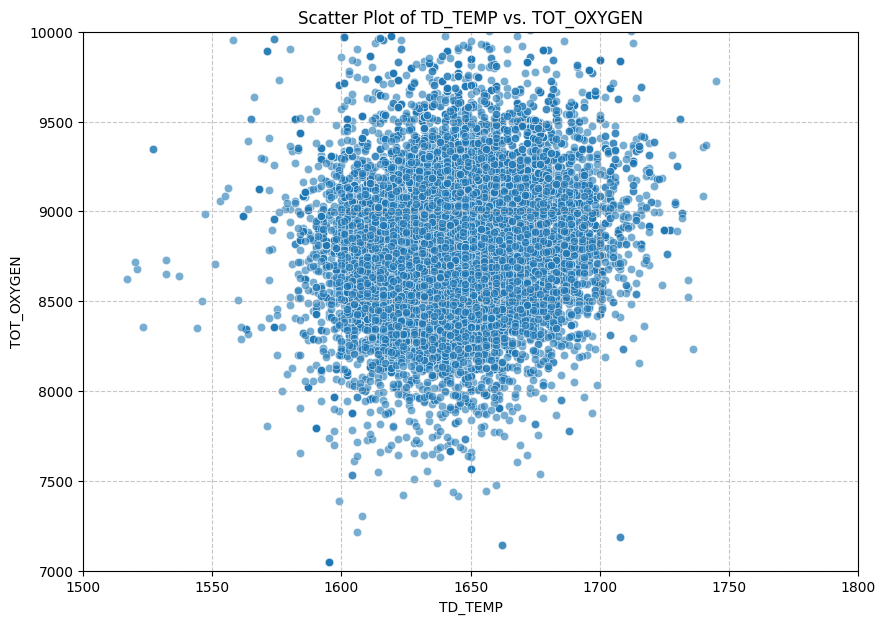

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='TD_TEMP', y='TOT_OXYGEN', alpha=0.6)
plt.title('Scatter Plot of TD_TEMP vs. TOT_OXYGEN')
plt.xlabel('TD_TEMP')
plt.ylabel('TOT_OXYGEN')
plt.xlim(1500, 1800)
plt.ylim(7000, 10000)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [23]:
import numpy as np

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Filter for only positive values in numeric columns
positive_numeric_df = numeric_df[numeric_df > 0]

# Calculate correlation of 'TD_TEMP' with other numeric columns (only positive values)
if 'TD_TEMP' in positive_numeric_df.columns:
    correlations_positive = positive_numeric_df.corr()['TD_TEMP'].sort_values(ascending=False)
    print("Correlation of 'TD_TEMP' with other numeric columns (positive values only):")
    print(correlations_positive)
else:
    print("'TD_TEMP' does not have positive values or is not a numeric column in the filtered data. Cannot calculate correlation.")

Correlation of 'TD_TEMP' with other numeric columns (positive values only):
TD_TEMP       1.000000
P_VALUE       0.295738
HEATNO        0.155442
BSP_HEATNO    0.155427
SN_VALUE      0.110773
                ...   
PB_VALUE           NaN
W_FLAG             NaN
W_VALUE            NaN
FE_P_FLAG          NaN
N_VALUE            NaN
Name: TD_TEMP, Length: 75, dtype: float64
